# Compile MDP Adapatation Results <br>
Date: 11/04/2024

## Compile MCS Results

### Detailed Results for Each Test Case

In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

BASE_DATASET_PATH = "/media/research-student/KingstonSSD/mcs_adaptation_results/"
MODEL ="snr_based_min_pkt_size_90_processed"
         # For copy pasting:
         # "bn_proposed_99_processed", "bn_proposed_999_processed", "nn_proposed_99_processed", "nn_proposed_999_processed", "nn_calibrated_specificity_99_processed", "nn_calibrated_specificity_999_processed",
         # "intel_mcs_scaling_99_processed", "intel_mcs_scaling_999_processed", "OLD_13062024/snr_based_max_pkt_size_99_processed", "OLD_13062024/snr_based_max_pkt_size_999_processed", 
         # "OLD_13062024/snr_based_min_pkt_size_99_processed", "OLD_13062024/snr_based_min_pkt_size_999_processed"
DATA_PATH = os.path.join(BASE_DATASET_PATH, MODEL)
NUM_RUNS = 500

# Get the reliability th
if "_999_" in MODEL:
    reliability_th = 0.999
elif "_99_" in MODEL:
    reliability_th = 0.99
elif "_90_" in MODEL:
    reliability_th = 0.9

# Specify order to process results (for convenience)
uav_speed_order = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
                   16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,
                   26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26]
height_order = [75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285,
                75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285,
                75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 75, 135, 195, 255, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285, 105, 165, 225, 285]
usi_order = [10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10, 10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10,
             10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10, 10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10,
             10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10, 10, 20, 66.7, 100, 20, 10, 100, 66.7, 66.7, 100, 10, 20, 100, 66.7, 20, 10]

test_results = []
scenario_list = [f.path for f in os.scandir(DATA_PATH) if f.is_dir()]
for scenario in tqdm(scenario_list):
    scenario_params = scenario.split('_')
    uav_speed = int([param for param in scenario_params if ("UAVSpeed" in param)][0].split('-')[-1])
    height = int([param for param in scenario_params if ("Height" in param)][0].split('-')[-1])
    h_dist = int([param for param in scenario_params if ("Distance" in param)][0].split('-')[-1])
    uav_sending_interval = float([param for param in scenario_params if ("UAVSendingInterval" in param)][0].split('-')[-1])
    results_df = pd.read_csv(os.path.join(scenario, "Simulation_Results.csv"))
    results_df = results_df[0:NUM_RUNS]
    results_df["Reliability_Maintained"] = (results_df["Total_Reliability_DL"] >= reliability_th) & (results_df["Total_Reliability_UL"] >= reliability_th) & (results_df["Total_Reliability_VID"] >= reliability_th) 
    num_runs = len(results_df)
    num_maintained = len(results_df.loc[results_df["Reliability_Maintained"] == True])
    mean_reliability_dl = results_df["Total_Reliability_DL"].mean()
    min_reliability_dl = results_df["Total_Reliability_DL"].min()
    max_reliability_dl = results_df["Total_Reliability_DL"].max()
    mean_delay_excd_dl = results_df["Total_Delay_Excd_DL"].mean()
    mean_incr_rcvd_dl = results_df["Total_Incr_Rcvd_DL"].mean()
    mean_q_overflow_dl = results_df["Total_Q_Overflow_DL"].mean()
    mean_reliability_ul = results_df["Total_Reliability_UL"].mean()
    min_reliability_ul = results_df["Total_Reliability_UL"].min()
    max_reliability_ul = results_df["Total_Reliability_UL"].max()
    mean_delay_excd_ul = results_df["Total_Delay_Excd_UL"].mean()
    mean_incr_rcvd_ul = results_df["Total_Incr_Rcvd_UL"].mean()
    mean_q_overflow_ul = results_df["Total_Q_Overflow_UL"].mean()
    mean_reliability_vid = results_df["Total_Reliability_VID"].mean()
    min_reliability_vid = results_df["Total_Reliability_VID"].min()
    max_reliability_vid = results_df["Total_Reliability_VID"].max()
    mean_delay_excd_vid = results_df["Total_Delay_Excd_VID"].mean()
    mean_incr_rcvd_vid = results_df["Total_Incr_Rcvd_VID"].mean()
    mean_q_overflow_vid = results_df["Total_Q_Overflow_VID"].mean()
    test_results.append({"UAV_Speed": uav_speed, "UAV_Sending_Interval": uav_sending_interval, "Height": height, "Max_HDist": h_dist, "Percentage_Maintained": num_maintained/num_runs,
                        "Mean_Reliability_DL": mean_reliability_dl, "Min_Reliability_DL": min_reliability_dl, "Max_Reliability_DL": max_reliability_dl, "Mean_Delay_Excd_DL": mean_delay_excd_dl, "Mean_Incr_Rcvd_DL": mean_incr_rcvd_dl, "Mean_Q_Overflow_DL": mean_q_overflow_dl,
                        "Mean_Reliability_UL": mean_reliability_ul, "Min_Reliability_UL": min_reliability_ul, "Max_Reliability_UL": max_reliability_ul, "Mean_Delay_Excd_UL": mean_delay_excd_ul, "Mean_Incr_Rcvd_UL": mean_incr_rcvd_ul, "Mean_Q_Overflow_UL": mean_q_overflow_ul,
                        "Mean_Reliability_VID": mean_reliability_vid, "Min_Reliability_VID": min_reliability_vid, "Max_Reliability_VID": max_reliability_vid, "Mean_Delay_Excd_VID": mean_delay_excd_vid, "Mean_Incr_Rcvd_VID": mean_incr_rcvd_vid, "Mean_Q_Overflow_VID": mean_q_overflow_vid})

test_results_df = pd.DataFrame(test_results)

# Sort by test cases
test_results_sorted = []
for i in range(len(height_order)):
    test_results_sorted.append(test_results_df.loc[(test_results_df["UAV_Speed"]==uav_speed_order[i]) & (test_results_df["UAV_Sending_Interval"]==usi_order[i]) &
                                                      (test_results_df["Height"]==height_order[i])])
test_results_sorted_df = pd.concat(test_results_sorted)
test_results_sorted_df.to_csv(os.path.join("/media/research-student/KingstonSSD/mcs_adaptation_results", "{}_results_{}_runs.csv".format(MODEL, NUM_RUNS)))

 71%|███████   | 68/96 [00:00<00:00, 220.43it/s]

100%|██████████| 96/96 [00:00<00:00, 221.18it/s]


### Compile Percentage Maintained (over all runs) for each Model across each Test Case

In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

def scantree(path):
    """Recursively yield DirEntry objects for given directory."""
    for entry in os.scandir(path):
        if entry.is_dir(follow_symlinks=False):
            yield from scantree(entry.path)  # see below for Python 2.x
        else:
            yield entry

BASE_DATASET_PATH = "/media/research-student/KingstonSSD/mcs_adaptation_results/"
MODELS = ["bn_proposed_90_processed", "bn_proposed_99_processed", "bn_proposed_999_processed", 
          "nn_proposed_90_processed", "nn_proposed_99_processed", "nn_proposed_999_processed", 
          "nn_calibrated_specificity_90_processed", "nn_calibrated_specificity_99_processed", "nn_calibrated_specificity_999_processed",
          "intel_mcs_scaling_90_processed", "intel_mcs_scaling_99_processed", "intel_mcs_scaling_999_processed", 
          "snr_based_max_pkt_size_90_processed", "snr_based_max_pkt_size_99_processed", "snr_based_max_pkt_size_999_processed", 
          "snr_based_min_pkt_size_90_processed", "snr_based_min_pkt_size_99_processed", "snr_based_min_pkt_size_999_processed"]
NUM_RUNS = 100
results = []
for model in MODELS:
    # Get the reliability th
    if "_999_" in model:
        reliability_th = 0.999
    elif "_99_" in model:
        reliability_th = 0.99
    elif "_90_" in model:
        reliability_th = 0.9

    dataset_path = os.path.join(BASE_DATASET_PATH, model)
    # Process UAV Speed 6 m/s 
    sim_files = [f.path for f in scantree(dataset_path) if (f.path.endswith(".csv") and "UAVSpeed-6_" in f.path)]
    if (reliability_th == 0.999):
        sim_files = [f for f in sim_files if ("UAVSpeed-6_Height-255_Distance-5_UAVSendingInterval-10" not in f and "UAVSpeed-6_Height-285_Distance-5_UAVSendingInterval-10" not in f)]
    num_runs = 0
    num_maintained = 0 # To count the number of runs where reliability is maintained
    for f in sim_files:
        df = pd.read_csv(f)
        df = df[0:NUM_RUNS]
        df["Reliability_Maintained"] = (df["Total_Reliability_DL"] >= reliability_th) & (df["Total_Reliability_UL"] >= reliability_th) & (df["Total_Reliability_VID"] >= reliability_th) 
        num_runs += len(df)
        num_maintained += len(df.loc[df["Reliability_Maintained"] == True])
    results.append({"UAV_Speed": 6, "Model": model, "Num_Runs": num_runs, "Num_Maintained": num_maintained})
    # Process UAV Speed 16 m/s 
    sim_files = [f.path for f in scantree(dataset_path) if (f.path.endswith(".csv") and "UAVSpeed-16_" in f.path)]
    if (reliability_th == 0.999):
        sim_files = [f for f in sim_files if ("UAVSpeed-16_Height-255_Distance-5_UAVSendingInterval-10" not in f and "UAVSpeed-16_Height-285_Distance-5_UAVSendingInterval-10" not in f)]
    num_runs = 0
    num_maintained = 0 # To count the number of runs where reliability is maintained
    for f in sim_files:
        df = pd.read_csv(f)
        df = df[0:NUM_RUNS]
        df["Reliability_Maintained"] = (df["Total_Reliability_DL"] >= reliability_th) & (df["Total_Reliability_UL"] >= reliability_th) & (df["Total_Reliability_VID"] >= reliability_th) 
        num_runs += len(df)
        num_maintained += len(df.loc[df["Reliability_Maintained"] == True])
    results.append({"UAV_Speed": 16, "Model": model, "Num_Runs": num_runs, "Num_Maintained": num_maintained})
    # Process UAV Speed 26 m/s 
    sim_files = [f.path for f in scantree(dataset_path) if (f.path.endswith(".csv") and "UAVSpeed-26_" in f.path)]
    if (reliability_th == 0.999):
        sim_files = [f for f in sim_files if ("UAVSpeed-26_Height-255_Distance-5_UAVSendingInterval-10" not in f and "UAVSpeed-26_Height-285_Distance-5_UAVSendingInterval-10" not in f)]
    num_runs = 0
    num_maintained = 0 # To count the number of runs where reliability is maintained
    for f in sim_files:
        df = pd.read_csv(f)
        df = df[0:NUM_RUNS]
        df["Reliability_Maintained"] = (df["Total_Reliability_DL"] >= reliability_th) & (df["Total_Reliability_UL"] >= reliability_th) & (df["Total_Reliability_VID"] >= reliability_th) 
        num_runs += len(df)
        num_maintained += len(df.loc[df["Reliability_Maintained"] == True])
    results.append({"UAV_Speed": 26, "Model": model, "Num_Runs": num_runs, "Num_Maintained": num_maintained})
        
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join("/media/research-student/KingstonSSD/mcs_adaptation_results", "MCS_Adaptation_Percentage_Results_{}_Runs.csv".format(NUM_RUNS)))

## Compile USI Adaptation Results

### Detailed Results for Each Test Case

In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

BASE_DATASET_PATH = "/media/research-student/KingstonSSD/usi_adaptation_results/"
MODEL ="nn_proposed_999_processed"
         # For copy pasting:
         # "bn_proposed_99_processed", "bn_proposed_999_processed", "nn_proposed_99_processed", "nn_proposed_999_processed", "nn_calibrated_specificity_99_processed", "nn_calibrated_specificity_999_processed",
         
DATA_PATH = os.path.join(BASE_DATASET_PATH, MODEL)

# Get the reliability th
if "_999_" in MODEL:
    reliability_th = 0.999
    uav_speed_order = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
                    6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
                    16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
                    16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
                    26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26,
                    26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26]
    height_order = [75,75,75,75,75,75,75,105,105,105,105,105,105,105,135,135,135,135,135,135,165,165,165,165,
                    195,195,195,195,225,225,225,225,255,255,255,255,285,285,285,
                    75,75,75,75,75,75,75,105,105,105,105,105,105,105,135,135,135,135,135,135,165,165,165,165,
                    195,195,195,195,225,225,225,225,255,255,255,255,285,285,285,
                    75,75,75,75,75,75,75,105,105,105,105,105,105,105,135,135,135,135,135,135,165,165,165,165,
                    195,195,195,195,225,225,225,225,255,255,255,255,285,285,285]
    bitrate_order = [13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 65,
                    13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26,
                    13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 65,
                    13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26,
                    13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 65,
                    13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26]
elif "_99_" in MODEL:
    reliability_th = 0.99
    uav_speed_order = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
                    6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
                    16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
                    16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
                    26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26,
                    26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26,]
    height_order = [75,75,75,75,75,75,75,75,105,105,105,105,105,105,105,105,135,135,135,135,135,135,135,135,165,165,165,165,165, \
                    195,195,195,195,195,225,225,225,225,225,255,255,255,255,255,285,285,285,285,
                    75,75,75,75,75,75,75,75,105,105,105,105,105,105,105,105,135,135,135,135,135,135,135,135,165,165,165,165,165, \
                    195,195,195,195,195,225,225,225,225,225,255,255,255,255,255,285,285,285,285,
                    75,75,75,75,75,75,75,75,105,105,105,105,105,105,105,105,135,135,135,135,135,135,135,135,165,165,165,165,165, \
                    195,195,195,195,195,225,225,225,225,225,255,255,255,255,255,285,285,285,285]
    bitrate_order = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65, 6.5, 13, 19.5, 26, 39, 52, 58.5, 65, 6.5, 13, 19.5, 26, 39, 52, 58.5, 65,
                    6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26,
                    6.5, 13, 19.5, 26, 39, 52, 58.5, 65, 6.5, 13, 19.5, 26, 39, 52, 58.5, 65, 6.5, 13, 19.5, 26, 39, 52, 58.5, 65,
                    6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26,
                    6.5, 13, 19.5, 26, 39, 52, 58.5, 65, 6.5, 13, 19.5, 26, 39, 52, 58.5, 65, 6.5, 13, 19.5, 26, 39, 52, 58.5, 65,
                    6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26, 39, 6.5, 13, 19.5, 26]

test_results = []
scenario_list = [f.path for f in os.scandir(DATA_PATH) if f.is_dir()]
for scenario in tqdm(scenario_list):
    scenario_params = scenario.split('_')
    uav_speed = int([param for param in scenario_params if ("UAVSpeed" in param)][0].split('-')[-1])
    height = int([param for param in scenario_params if ("Height" in param)][0].split('-')[-1])
    h_dist = int([param for param in scenario_params if ("Distance" in param)][0].split('-')[-1])
    bitrate = float([param for param in scenario_params if ("BitRate" in param)][0].split('-')[-1])
    results_df = pd.read_csv(os.path.join(scenario, "Simulation_Results.csv"))
    results_df["Reliability_Maintained"] = (results_df["Total_Reliability_DL"] >= reliability_th) & (results_df["Total_Reliability_UL"] >= reliability_th) & (results_df["Total_Reliability_VID"] >= reliability_th) 
    num_runs = len(results_df)
    num_maintained = len(results_df.loc[results_df["Reliability_Maintained"] == True])
    mean_reliability_dl = results_df["Total_Reliability_DL"].mean()
    min_reliability_dl = results_df["Total_Reliability_DL"].min()
    mean_delay_excd_dl = results_df["Total_Delay_Excd_DL"].mean()
    mean_incr_rcvd_dl = results_df["Total_Incr_Rcvd_DL"].mean()
    mean_q_overflow_dl = results_df["Total_Q_Overflow_DL"].mean()
    mean_reliability_ul = results_df["Total_Reliability_UL"].mean()
    min_reliability_ul = results_df["Total_Reliability_UL"].min()
    mean_delay_excd_ul = results_df["Total_Delay_Excd_UL"].mean()
    mean_incr_rcvd_ul = results_df["Total_Incr_Rcvd_UL"].mean()
    mean_q_overflow_ul = results_df["Total_Q_Overflow_UL"].mean()
    mean_reliability_vid = results_df["Total_Reliability_VID"].mean()
    min_reliability_vid = results_df["Total_Reliability_VID"].min()
    mean_delay_excd_vid = results_df["Total_Delay_Excd_VID"].mean()
    mean_incr_rcvd_vid = results_df["Total_Incr_Rcvd_VID"].mean()
    mean_q_overflow_vid = results_df["Total_Q_Overflow_VID"].mean()
    test_results.append({"UAV_Speed": uav_speed, "BitRate": bitrate, "Height": height, "Max_HDist": h_dist, "Percentage_Maintained": num_maintained/num_runs,
                        "Mean_Reliability_DL": mean_reliability_dl, "Min_Reliability_DL": min_reliability_dl, "Mean_Delay_Excd_DL": mean_delay_excd_dl, "Mean_Incr_Rcvd_DL": mean_incr_rcvd_dl, "Mean_Q_Overflow_DL": mean_q_overflow_dl,
                        "Mean_Reliability_UL": mean_reliability_ul, "Min_Reliability_UL": min_reliability_ul, "Mean_Delay_Excd_UL": mean_delay_excd_ul, "Mean_Incr_Rcvd_UL": mean_incr_rcvd_ul, "Mean_Q_Overflow_UL": mean_q_overflow_ul,
                        "Mean_Reliability_VID": mean_reliability_vid, "Min_Reliability_VID": min_reliability_vid, "Mean_Delay_Excd_VID": mean_delay_excd_vid, "Mean_Incr_Rcvd_VID": mean_incr_rcvd_vid, "Mean_Q_Overflow_VID": mean_q_overflow_vid})

test_results_df = pd.DataFrame(test_results)

# Sort by test cases
test_results_sorted = []
for i in range(len(height_order)):
    test_results_sorted.append(test_results_df.loc[(test_results_df["UAV_Speed"]==uav_speed_order[i]) & (test_results_df["BitRate"]==bitrate_order[i]) &
                                                      (test_results_df["Height"]==height_order[i])])
test_results_sorted_df = pd.concat(test_results_sorted)
test_results_sorted_df.to_csv(os.path.join("/media/research-student/KingstonSSD/usi_adaptation_results", "{}_results.csv".format(MODEL)))

 39%|███▉      | 46/117 [00:00<00:00, 215.79it/s]

100%|██████████| 117/117 [00:00<00:00, 215.23it/s]


### Compile Percentage Maintained (over all runs) for each Model across each Test Case

In [6]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

def scantree(path):
    """Recursively yield DirEntry objects for given directory."""
    for entry in os.scandir(path):
        if entry.is_dir(follow_symlinks=False):
            yield from scantree(entry.path)  # see below for Python 2.x
        else:
            yield entry

BASE_DATASET_PATH = "/media/research-student/KingstonSSD/usi_adaptation_results/"
MODELS = ["bn_proposed_90_processed", "bn_proposed_99_processed", "bn_proposed_999_processed", 
          "nn_proposed_90_processed", "nn_proposed_99_processed", "nn_proposed_999_processed", 
          "nn_calibrated_specificity_90_processed", "nn_calibrated_specificity_99_processed", "nn_calibrated_specificity_999_processed"]
NUM_RUNS = 100

results = []
for model in MODELS:
    # Get the reliability th
    if "_999_" in model:
        reliability_th = 0.999
    elif "_99_" in model:
        reliability_th = 0.99
    elif "_90_" in model:
        reliability_th = 0.9

    dataset_path = os.path.join(BASE_DATASET_PATH, model)
    # Process UAV Speed 6 m/s 
    sim_files = [f.path for f in scantree(dataset_path) if (f.path.endswith(".csv") and "UAVSpeed-6_" in f.path)]
    if (reliability_th == 0.99):
        sim_files = [f for f in sim_files if ("_BitRate-6.5" not in f)] # Exclude BPSK cases
    num_runs = 0
    num_maintained = 0 # To count the number of runs where reliability is maintained
    for f in sim_files:
        df = pd.read_csv(f)
        df.sort_index(inplace=True)
        df = df[-NUM_RUNS:]
        df["Reliability_Maintained"] = (df["Total_Reliability_DL"] >= reliability_th) & (df["Total_Reliability_UL"] >= reliability_th) & (df["Total_Reliability_VID"] >= reliability_th) 
        num_runs += len(df)
        num_maintained += len(df.loc[df["Reliability_Maintained"] == True])
    results.append({"UAV_Speed": 6, "Model": model, "Num_Runs": num_runs, "Num_Maintained": num_maintained})
    # Process UAV Speed 16 m/s 
    sim_files = [f.path for f in scantree(dataset_path) if (f.path.endswith(".csv") and "UAVSpeed-16_" in f.path)]
    if (reliability_th == 0.99):
        sim_files = [f for f in sim_files if ("_BitRate-6.5" not in f)] # Exclude BPSK cases
    num_runs = 0
    num_maintained = 0 # To count the number of runs where reliability is maintained
    for f in sim_files:
        df = pd.read_csv(f)
        df.sort_index(inplace=True)
        df = df[-NUM_RUNS:]
        df["Reliability_Maintained"] = (df["Total_Reliability_DL"] >= reliability_th) & (df["Total_Reliability_UL"] >= reliability_th) & (df["Total_Reliability_VID"] >= reliability_th) 
        num_runs += len(df)
        num_maintained += len(df.loc[df["Reliability_Maintained"] == True])
    results.append({"UAV_Speed": 16, "Model": model, "Num_Runs": num_runs, "Num_Maintained": num_maintained})
    # Process UAV Speed 26 m/s 
    sim_files = [f.path for f in scantree(dataset_path) if (f.path.endswith(".csv") and "UAVSpeed-26_" in f.path)]
    if (reliability_th == 0.99):
        sim_files = [f for f in sim_files if ("_BitRate-6.5" not in f)] # Exclude BPSK cases
    num_runs = 0
    num_maintained = 0 # To count the number of runs where reliability is maintained
    for f in sim_files:
        df = pd.read_csv(f)
        df.sort_index(inplace=True)
        df = df[-NUM_RUNS:]
        df["Reliability_Maintained"] = (df["Total_Reliability_DL"] >= reliability_th) & (df["Total_Reliability_UL"] >= reliability_th) & (df["Total_Reliability_VID"] >= reliability_th) 
        num_runs += len(df)
        num_maintained += len(df.loc[df["Reliability_Maintained"] == True])
    results.append({"UAV_Speed": 26, "Model": model, "Num_Runs": num_runs, "Num_Maintained": num_maintained})
        
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join("/media/research-student/KingstonSSD/usi_adaptation_results", "USI_Adaptation_Percentage_Results_{}_Runs.csv".format(NUM_RUNS)))


## Compile Height Adaptation Results

In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

DATA_PATH = "/media/research-student/KingstonSSD/height_adaptation_results/bn_proposed_99_processed/"

# Specify order to process results (for convenience)
# # For 99% reliability
uav_speed_order = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
init_height_order = [180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 
                     180, 180, 180, 180, 180, 180]
usi_order = [10, 10, 10, 10, 10, 20, 20, 20, 20, 20, 20, 20, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 100, 100, 100, 100, 100, 100, 100]
mcs_order = [3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7]

# For 99.9% reliability
# uav_speed_order = [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
#                    6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
# height_order = [75,75,75,75,75,75,75,105,105,105,105,105,105,105,135,135,135,135,135,135,165,165,165,165,
#                 195,195,195,195,225,225,225,225,255,255,255,255,285,285,285]
# bitrate_order = [13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 58.5, 65, 13, 19.5, 26, 39, 52, 65,
#                 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26, 39, 13, 19.5, 26]

test_results = []
scenario_list = [f.path for f in os.scandir(DATA_PATH) if f.is_dir()]
for scenario in tqdm(scenario_list):
    scenario_params = scenario.split('_')
    uav_speed = int([param for param in scenario_params if ("uavspeed" in param)][0].split('-')[-1])
    init_height = int([param for param in scenario_params if ("initHeight" in param)][0].split('-')[-1])
    usi = float([param for param in scenario_params if ("usi" in param)][0].split('-')[-1])
    mcs = int([param for param in scenario_params if ("mcs" in param)][0].split('-')[-1])
    results_df = pd.read_csv(os.path.join(scenario, "Simulation_Results.csv"))
    mean_reliability_dl = results_df["Total_Reliability_DL"].mean()
    min_reliability_dl = results_df["Total_Reliability_DL"].min()
    mean_delay_excd_dl = results_df["Total_Delay_Excd_DL"].mean()
    mean_incr_rcvd_dl = results_df["Total_Incr_Rcvd_DL"].mean()
    mean_q_overflow_dl = results_df["Total_Q_Overflow_DL"].mean()
    mean_reliability_ul = results_df["Total_Reliability_UL"].mean()
    min_reliability_ul = results_df["Total_Reliability_UL"].min()
    mean_delay_excd_ul = results_df["Total_Delay_Excd_UL"].mean()
    mean_incr_rcvd_ul = results_df["Total_Incr_Rcvd_UL"].mean()
    mean_q_overflow_ul = results_df["Total_Q_Overflow_UL"].mean()
    mean_reliability_vid = results_df["Total_Reliability_VID"].mean()
    min_reliability_vid = results_df["Total_Reliability_VID"].min()
    mean_delay_excd_vid = results_df["Total_Delay_Excd_VID"].mean()
    mean_incr_rcvd_vid = results_df["Total_Incr_Rcvd_VID"].mean()
    mean_q_overflow_vid = results_df["Total_Q_Overflow_VID"].mean()
    test_results.append({"UAV_Speed": uav_speed, "Init_Height": init_height, "USI": usi, "MCS": mcs,
                        "Mean_Reliability_DL": mean_reliability_dl, "Min_Reliability_DL": min_reliability_dl, "Mean_Delay_Excd_DL": mean_delay_excd_dl, "Mean_Incr_Rcvd_DL": mean_incr_rcvd_dl, "Mean_Q_Overflow_DL": mean_q_overflow_dl,
                        "Mean_Reliability_UL": mean_reliability_ul, "Min_Reliability_UL": min_reliability_ul, "Mean_Delay_Excd_UL": mean_delay_excd_ul, "Mean_Incr_Rcvd_UL": mean_incr_rcvd_ul, "Mean_Q_Overflow_UL": mean_q_overflow_ul,
                        "Mean_Reliability_VID": mean_reliability_vid, "Min_Reliability_VID": min_reliability_vid, "Mean_Delay_Excd_VID": mean_delay_excd_vid, "Mean_Incr_Rcvd_VID": mean_incr_rcvd_vid, "Mean_Q_Overflow_VID": mean_q_overflow_vid})

test_results_df = pd.DataFrame(test_results)

# Sort by test cases
test_results_sorted = []
for i in range(len(init_height_order)):
    test_results_sorted.append(test_results_df.loc[(test_results_df["UAV_Speed"]==uav_speed_order[i]) & (test_results_df["Init_Height"]==init_height_order[i]) &
                                                      (test_results_df["USI"]==usi_order[i]) & (test_results_df["MCS"]==mcs_order[i])])
test_results_sorted_df = pd.concat(test_results_sorted)
test_results_sorted_df.to_csv(os.path.join("/media/research-student/KingstonSSD/height_adaptation_results", "bn_proposed_99_processed_results.csv"))

### Plot Bar Chart of Number of Satisfied Test Cases

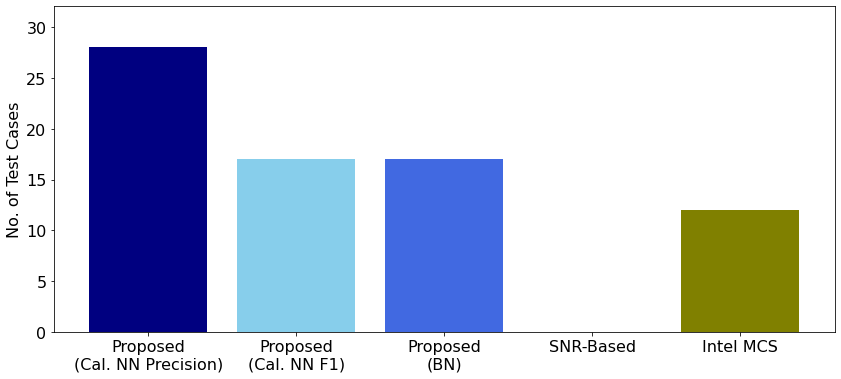

In [23]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})

scheme = ['Proposed\n(Cal. NN Precision)', 'Proposed\n(Cal. NN F1)', 'Proposed\n(BN)', 'SNR-Based', 'Intel MCS']
counts = [28, 17, 17, 0, 12] # The number of test cases satifying reliability requirement for all links
# bar_labels = ['red', 'blue', '_red', 'orange']
bar_colors = ['navy', 'skyblue', 'royalblue', 'maroon', 'olive']

ax.bar(scheme, counts, color=bar_colors)

ax.set_ylabel('No. of Test Cases')
ax.set_ylim(0, 32)
# ax.set_title('Fruit supply by kind and color')
# ax.legend(title='Fruit color')

plt.show()

## To say that more than 10% of packets failed due to delay excd or q overflow under Intel MCS Scaling for USI 10ms/20ms.

In [24]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

BASE_DATASET_PATH = "/media/research-student/KingstonSSD/mcs_adaptation_results/"
RESULTS ="intel_mcs_scaling_999_processed_results_500_runs.csv"
DATA_PATH = os.path.join(BASE_DATASET_PATH, RESULTS)

if "_999_" in RESULTS:
    reliability_th = 0.999
elif "_99_" in RESULTS:
    reliability_th = 0.99

results_df = pd.read_csv(DATA_PATH)
if (reliability_th == 0.999):
    results_df = results_df.loc[(results_df["UAV_Sending_Interval"] != 10.0) & (results_df["Height"] != 255)]
    results_df = results_df.loc[(results_df["UAV_Sending_Interval"] != 10.0) & (results_df["Height"] != 285)]

# Get test cases with USI either 10 ms or 20 ms
results_usi_10_20 = results_df[(results_df["UAV_Sending_Interval"] == 10.0) | (results_df["UAV_Sending_Interval"] == 20.0)]

# Get mean percentage of packets failed due to delay excd or q overflow
results_usi_10_20["Fail_DE_QO_DL"] = results_usi_10_20["Mean_Delay_Excd_DL"] + results_usi_10_20["Mean_Q_Overflow_DL"]
results_usi_10_20["Fail_DE_QO_UL"] = results_usi_10_20["Mean_Delay_Excd_UL"] + results_usi_10_20["Mean_Q_Overflow_UL"]

# Get percentage of test cases where DL/UL "Fail_DE_QL" is > 0.5
print("DL: {}".format(len(results_usi_10_20.loc[results_usi_10_20["Fail_DE_QO_DL"] > 0.1]) / len(results_usi_10_20)))
print("UL: {}".format(len(results_usi_10_20.loc[results_usi_10_20["Fail_DE_QO_UL"] > 0.1]) / len(results_usi_10_20)))



DL: 1.0
UL: 1.0


/tmp/ipykernel_3457418/3865634943.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_usi_10_20["Fail_DE_QO_DL"] = results_usi_10_20["Mean_Delay_Excd_DL"] + results_usi_10_20["Mean_Q_Overflow_DL"]
/tmp/ipykernel_3457418/3865634943.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_usi_10_20["Fail_DE_QO_UL"] = results_usi_10_20["Mean_Delay_Excd_UL"] + results_usi_10_20["Mean_Q_Overflow_UL"]
